In [9]:
folder_name = "/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/zdimitrov/tambo_simulations/pre_processed_3rd_step_min_50/train"

In [10]:
import os
os.listdir(folder_name)

['chunk_00138.pt',
 'chunk_00057.pt',
 'chunk_00109.pt',
 'chunk_00003.pt',
 'chunk_00163.pt',
 'chunk_00134.pt',
 'chunk_00207.pt',
 'chunk_00032.pt',
 'chunk_00034.pt',
 'chunk_00192.pt',
 'chunk_00212.pt',
 'chunk_00228.pt',
 'chunk_00058.pt',
 'chunk_00189.pt',
 'chunk_00005.pt',
 'chunk_00020.pt',
 'chunk_00042.pt',
 'chunk_00137.pt',
 'chunk_00105.pt',
 'chunk_00101.pt',
 'chunk_00151.pt',
 'chunk_00209.pt',
 'chunk_00075.pt',
 'chunk_00195.pt',
 'chunk_00110.pt',
 'chunk_00121.pt',
 'chunk_00008.pt',
 'chunk_00084.pt',
 'chunk_00068.pt',
 'chunk_00142.pt',
 'chunk_00230.pt',
 'chunk_00054.pt',
 'chunk_00260.pt',
 'chunk_00240.pt',
 'chunk_00176.pt',
 'chunk_00159.pt',
 'chunk_00063.pt',
 'chunk_00217.pt',
 'chunk_00227.pt',
 'chunk_00078.pt',
 'chunk_00051.pt',
 'chunk_00177.pt',
 'chunk_00255.pt',
 'chunk_00115.pt',
 'chunk_00007.pt',
 'chunk_00047.pt',
 'chunk_00080.pt',
 'chunk_00118.pt',
 'chunk_00035.pt',
 'chunk_00200.pt',
 'chunk_00128.pt',
 'chunk_00161.pt',
 'chunk_0006

In [11]:
import torch, sys, pprint

chunk = torch.load(folder_name + "/chunk_00000.pt", weights_only=False)

print("=== Top-level keys ===")
print(list(chunk.keys()))

print("\n=== Metadata ===")
pprint.pprint(chunk["metadata"])

print("\n=== Tensor shapes ===")
for k, v in chunk.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
    elif isinstance(v, dict) and k != "metadata":
        for k2, v2 in v.items():
            if isinstance(v2, torch.Tensor):
                print(f"  {k}.{k2}: shape={v2.shape}, dtype={v2.dtype}")


=== Top-level keys ===
['metadata', 'bbox_ranges', 'p_energy', 'sin_zenith', 'cos_zenith', 'sin_azimuth', 'cos_azimuth', 'class_id', 'file_paths']

=== Metadata ===
{'balance_method': 'none',
 'chunk_end': 500,
 'chunk_index': 0,
 'chunk_size': 500,
 'chunk_start': 0,
 'n_chunks': 261,
 'n_samples': 500,
 'n_sources': 5,
 'notes': 'Data saved WITHOUT normalization. Normalization will be applied '
          'during training.',
 'seed': 24,
 'source_files': ['/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/zdimitrov/tambo_simulations/pre_processed_2nd_step_min_50/pdg_111/bboxes.pt',
                  '/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/zdimitrov/tambo_simulations/pre_processed_2nd_step_min_50/pdg_-11/bboxes.pt',
                  '/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/zdimitrov/tambo_simulations/pre_processed_2nd_step_min_50/pdg_11/bboxes.pt',
                  '/n/holylfs05/LABS/arguelles_delgado_lab/Everyone/zdimitrov/tambo_simulations/pre_processed_2nd_step_m

In [13]:
import torch, os

split_dir = folder_name
chunk_files = sorted(f for f in os.listdir(split_dir) if f.endswith(".pt"))

header = (f"{'Chunk':<20} {'N':>5} "
          f"{'zen_min':>10} {'zen_max':>10} "
          f"{'azi_min':>10} {'azi_max':>10} "
          f"{'E_min':>12} {'E_max':>12} "
          f"{'bbox_min':>10} {'bbox_max':>10} "
          f"{'classes':>20}")
print(header)
print("-" * len(header))

for cf in chunk_files:
    c = torch.load(os.path.join(split_dir, cf), weights_only=False)

    zenith  = torch.rad2deg(torch.atan2(c["sin_zenith"],  c["cos_zenith"]))
    azimuth = torch.rad2deg(torch.atan2(c["sin_azimuth"], c["cos_azimuth"]))
    energy  = c["p_energy"]
    bbox    = c["bbox_ranges"]
    classes = c["class_id"]

    unique_cls = sorted(classes.unique().tolist())

    print(f"{cf:<20} {classes.shape[0]:>5} "
          f"{zenith.min().item():>10.3f} {zenith.max().item():>10.3f} "
          f"{azimuth.min().item():>10.3f} {azimuth.max().item():>10.3f} "
          f"{energy.min().item():>12.4f} {energy.max().item():>12.4f} "
          f"{bbox.min().item():>10.4f} {bbox.max().item():>10.4f} "
          f"{str(unique_cls):>20}")

Chunk                    N    zen_min    zen_max    azi_min    azi_max        E_min        E_max   bbox_min   bbox_max              classes
-------------------------------------------------------------------------------------------------------------------------------------------
chunk_00000.pt         500      0.526    179.583   -178.918    179.621       0.0020       0.9953  -514.4574   904.4736            [0, 1, 2]
chunk_00001.pt         500      0.433    179.448   -179.300    179.409       0.0020       0.9854  -496.4833  1012.4869            [0, 1, 2]
chunk_00002.pt         500      0.545    179.381   -178.152    179.597       0.0020       0.9785  -606.0192   941.1149            [0, 1, 2]
chunk_00003.pt         500      0.189    179.561   -179.144    179.112       0.0020       0.9637  -468.1446   875.6642            [0, 1, 2]
chunk_00004.pt         500      0.018    179.347   -179.467    176.508       0.0021       0.9824  -481.0239   939.7380            [0, 1, 2]
chunk_00005.pt      

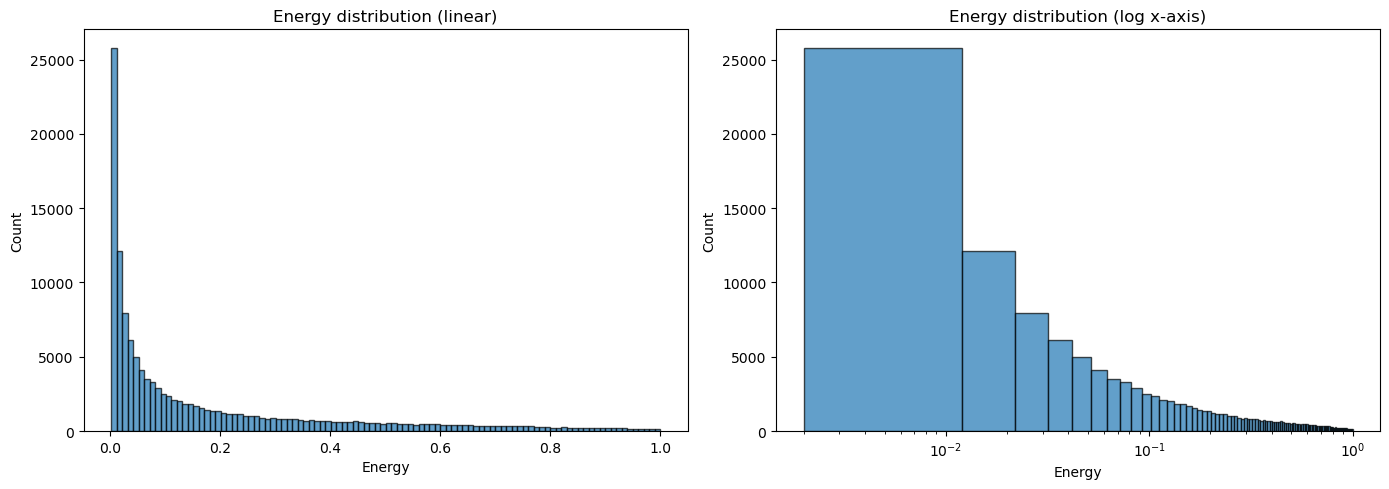

Total samples: 130125
Energy range: [0.0020, 1.0000]
Mean: 0.1812, Std: 0.2312


In [14]:
import torch, os
import matplotlib.pyplot as plt

split_dir = folder_name
chunk_files = sorted(f for f in os.listdir(split_dir) if f.endswith(".pt"))

all_energy = []
for cf in chunk_files:
    c = torch.load(os.path.join(split_dir, cf), weights_only=False)
    all_energy.append(c["p_energy"])

all_energy = torch.cat(all_energy).numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_energy, bins=100, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Energy")
axes[0].set_ylabel("Count")
axes[0].set_title("Energy distribution (linear)")

axes[1].hist(all_energy, bins=100, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Energy")
axes[1].set_ylabel("Count")
axes[1].set_xscale("log")
axes[1].set_title("Energy distribution (log x-axis)")

plt.tight_layout()
plt.show()

print(f"Total samples: {len(all_energy)}")
print(f"Energy range: [{all_energy.min():.4f}, {all_energy.max():.4f}]")
print(f"Mean: {all_energy.mean():.4f}, Std: {all_energy.std():.4f}")

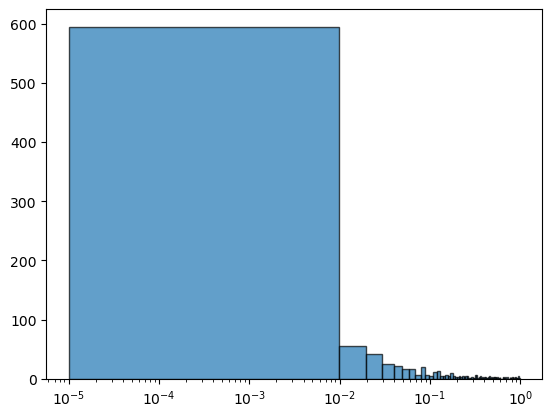

In [6]:
import torch
import matplotlib.pyplot as plt
number_of_showers = 1000
p_energy = torch.exp(torch.rand(number_of_showers) * (torch.log(torch.tensor(1.0)) - torch.log(torch.tensor(1e-5))) + torch.log(torch.tensor(1e-5)))

plt.hist(p_energy.numpy(), bins=100, edgecolor="black", alpha=0.7)
plt.xscale("log")

In [4]:
import torch
number_of_showers = 1000
class_id = torch.arange(3).repeat((number_of_showers + 2) // 3)[:number_of_showers].float()  # equal 0, 1, 2
class_id.shape

torch.Size([1000])